In [27]:
pip install pandas numpy nltk scikit-learn matplotlib wordcloud

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
import string

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from wordcloud import WordCloud

In [29]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [30]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [31]:
data = pd.read_csv(
    "/content/SMSSpamCollection",
    sep="\t",
    names=["label","message"]
)

print(data.head())

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [32]:
print(data.shape)

print(data.info())

print(data['label'].value_counts())

(5572, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
label
ham     4825
spam     747
Name: count, dtype: int64


In [33]:
print(data.isnull().sum())

label      0
message    0
dtype: int64


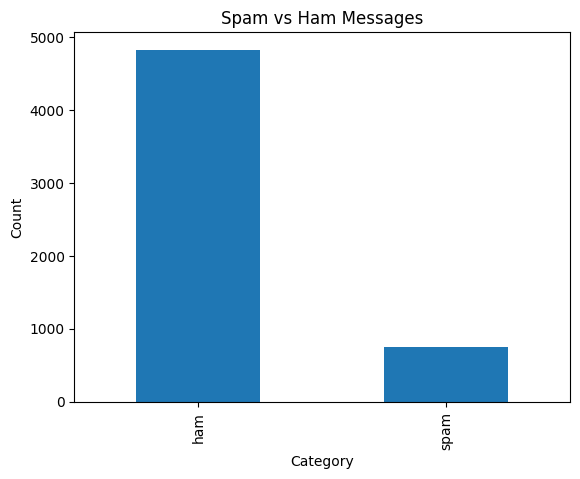

In [34]:
data['label'].value_counts().plot(kind='bar')

plt.title("Spam vs Ham Messages")

plt.xlabel("Category")

plt.ylabel("Count")

plt.show()

In [35]:
stemmer = PorterStemmer()

In [36]:
def preprocess(text):

    text = text.lower()

    text = "".join(
        char for char in text
        if char not in string.punctuation
    )

    words = text.split()

    words = [
        stemmer.stem(word)
        for word in words
        if word not in stopwords.words("english")
    ]

    return " ".join(words)

In [37]:
data['processed'] = data['message'].apply(preprocess)

In [38]:
print(data[['message','processed']].head())

                                             message  \
0  Go until jurong point, crazy.. Available only ...   
1                      Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup fina...   
3  U dun say so early hor... U c already then say...   
4  Nah I don't think he goes to usf, he lives aro...   

                                           processed  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri 2 wkli comp win fa cup final tkt 21...  
3                u dun say earli hor u c alreadi say  
4          nah dont think goe usf live around though  


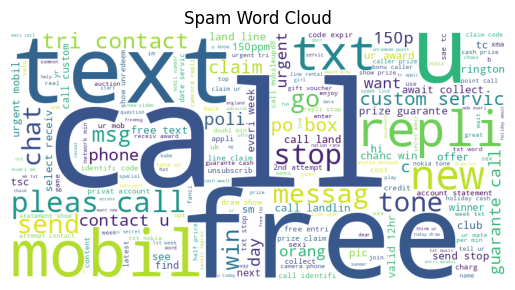

In [39]:
spam_words = " ".join(
    data[data['label']=="spam"]['processed']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(spam_words)

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Spam Word Cloud")

plt.show()

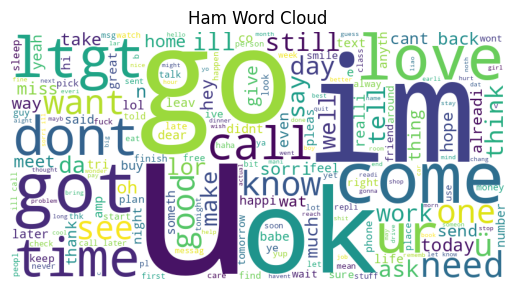

In [40]:
ham_words = " ".join(
    data[data['label']=="ham"]['processed']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(ham_words)

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Ham Word Cloud")

plt.show()

In [41]:
data['label'] = data['label'].map({

    'ham':0,

    'spam':1

})

In [42]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(data['processed'])

y = data['label']

In [43]:
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42
)

In [44]:
  model = MultinomialNB()

model.fit(X_train,y_train)

MultinomialNB()

In [45]:
prediction = model.predict(X_test)

In [46]:
accuracy = accuracy_score(y_test,prediction)

print("Accuracy =",accuracy)

Accuracy = 0.9650224215246637


In [47]:
print(classification_report(

    y_test,

    prediction
))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       966
           1       0.99      0.74      0.85       149

    accuracy                           0.97      1115
   macro avg       0.98      0.87      0.92      1115
weighted avg       0.97      0.97      0.96      1115



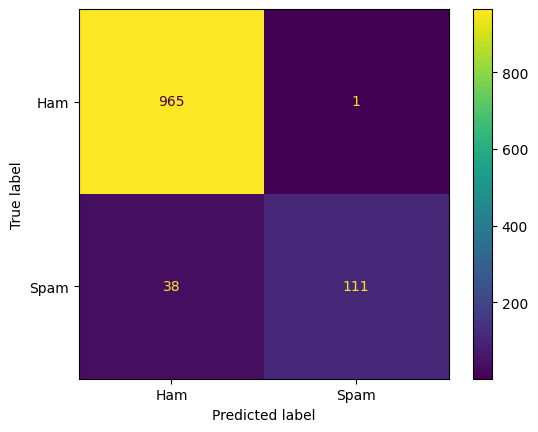

In [48]:
cm = confusion_matrix(

    y_test,

    prediction
)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=["Ham","Spam"]
)

disp.plot()

plt.show()

In [49]:
def predict_message(message):

    processed = preprocess(message)

    vector = vectorizer.transform([processed])

    prediction = model.predict(vector)

    if prediction[0]==1:

        print("Spam")

    else:

        print("Ham")

In [51]:
predict_message("Please attend the project meeting tomorrow at 10 AM.")

Ham
